In [204]:
import numpy             as np
import scipy.signal      as signal
import matplotlib.pyplot as plt
import soundfile         as sf
import librosa       
from scipy.io import wavfile
from scipy.signal import butter, lfilter    

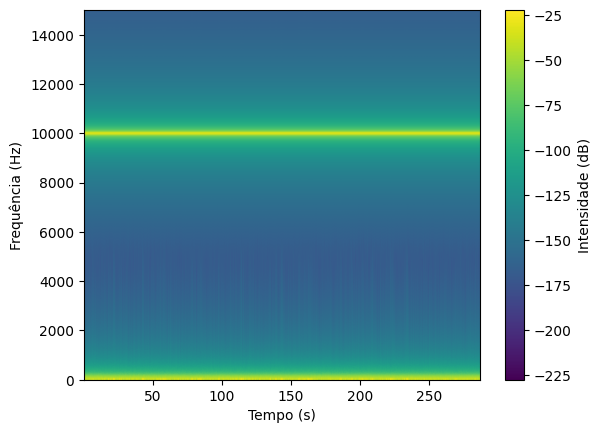

In [205]:
def gerar_ruido_rosa_filtrado(duracao_s, sample_rate, freq_max):
    n = int(duracao_s * sample_rate)
    uneven = n % 2
    X = np.random.randn(n // 2 + 1 + uneven) + 1j * np.random.randn(n // 2 + 1 + uneven)
    S = np.sqrt(1.0 / np.arange(1, len(X) + 1))
    y = np.fft.irfft(X * S).real[:n]
    
    # Filtro passa-baixas
    nyquist = 0.5 * sample_rate
    cutoff = freq_max / nyquist
    b, a = butter(4, cutoff, btype='lowpass')
    y_filtrado = lfilter(b, a, y)
    
    return y_filtrado / np.max(np.abs(y_filtrado))

def gerar_ruido_10khz(duracao_s, sample_rate, amplitude=0.5):
    t = np.linspace(0, duracao_s, int(duracao_s * sample_rate), endpoint=False)
    ruido_10k = amplitude * np.sin(2 * np.pi * 10000 * t)  # Onda senoidal em 10 kHz
    return ruido_10k

# Parâmetros
sample_rate = 48000  # Taxa de amostragem padrão para áudio
duracao = 287  # segundos
amplitude_10k = 0.3  # Amplitude do ruído de 10 kHz (ajuste conforme necessário)

# Gerar sinais
ruido_baixo = gerar_ruido_rosa_filtrado(duracao, sample_rate, 100)
ruido_alto = gerar_ruido_10khz(duracao, sample_rate, amplitude_10k)

# Combinar os sinais (soma simples)
sinal_combinado = ruido_baixo + ruido_alto

# Normalizar para evitar clipping
sinal_combinado = sinal_combinado / np.max(np.abs(sinal_combinado))

# Exportar para arquivo WAV
wavfile.write('ruido_combinado.wav', sample_rate, (sinal_combinado * 32767).astype(np.int16))

# Plot do espectro (opcional)
plt.specgram(sinal_combinado, Fs=sample_rate, NFFT=1024)
plt.xlabel('Tempo (s)')
plt.ylabel('Frequência (Hz)')
plt.colorbar(label='Intensidade (dB)')
plt.ylim(0, 15000)  # Focar na faixa relevante
plt.show()

In [206]:
def somar_wavs(arquivo1, arquivo2, arquivo_saida, ganho1=1.0, ganho2=1.0):
    # Carregar os arquivos WAV
    sr1, data1 = wavfile.read(arquivo1)
    sr2, data2 = wavfile.read(arquivo2)
    
    # Verificar taxas de amostragem
    if sr1 != sr2:
        raise ValueError("Taxas de amostragem diferentes!")
    
    # Converter para float32 e normalizar
    if data1.dtype != np.float32:
        data1 = data1.astype(np.float32) / (2**15 if data1.dtype == np.int16 else 2**31)
    if data2.dtype != np.float32:
        data2 = data2.astype(np.float32) / (2**15 if data2.dtype == np.int16 else 2**31)
    
    # Converter mono para estéreo se necessário
    if data1.ndim == 1 and data2.ndim == 2:
        data1 = np.column_stack((data1, data1))  # Duplica canal mono para estéreo
    elif data2.ndim == 1 and data1.ndim == 2:
        data2 = np.column_stack((data2, data2))  # Duplica canal mono para estéreo
    
    # Ajustar tamanhos
    len1 = len(data1)
    len2 = len(data2)
    
    if len1 > len2:
        if data2.ndim == 2:
            data2 = np.pad(data2, ((0, len1 - len2), (0, 0)), mode='constant')
        else:
            data2 = np.pad(data2, (0, len1 - len2), mode='constant')
    elif len2 > len1:
        if data1.ndim == 2:
            data1 = np.pad(data1, ((0, len2 - len1), (0, 0)), mode='constant')
        else:
            data1 = np.pad(data1, (0, len2 - len1), mode='constant')
    
    # Soma com ganhos
    soma = (data1 * ganho1) + (data2 * ganho2)
    
    # Normalização
    max_val = np.max(np.abs(soma))
    if max_val > 1.0:
        soma = soma / max_val
    
    # Correção do nome da função (era 'wawfile.write' e 'somar_ways')
    wavfile.write(arquivo_saida, sr1, (soma * 32767).astype(np.int16))

# Exemplo de uso CORRETO:
somar_wavs('ruido_combinado.wav', 'Jeff_Buckley.wav', 'soma.wav', ganho1=0.7, ganho2=0.3)


In [207]:
# fs = sr  # frequência de amostragem
# fc1 = 1    # frequência de corte inferior (Hz)
# fc2 = 100   # frequência de corte superior (Hz)
# norm_fc = [fc1 / (fs / 2), fc2 / (fs / 2)]  # normalizar ambas

In [208]:
fc1 = 9990    # frequência de corte inferior (Hz)
fc2 = 10010   # frequência de corte superior (Hz)
norm_fc = [fc1 / (fs / 2), fc2 / (fs / 2)]  # normalizar ambas

In [209]:
# FIR - janela de Hamming
fir_order = 11
fir_coeff = signal.firwin(fir_order, norm_fc, window='hamming', pass_zero=False)

In [210]:
# IIR - Butterworth 4ª ordem
iir_order = 3
b_iir, a_iir = signal.butter(iir_order, norm_fc,btype='bandpass')

In [211]:
# aplicação dos filtros
audio_ruidoso, fs = sf.read('soma.wav')
audio_fir = signal.lfilter(fir_coeff, 1.0,audio_ruidoso)
audio_iir = signal.lfilter(b_iir, a_iir, audio_ruidoso)

# salva arquivos filtrados
sf.write("JB_fir_filtrado_rosa_copia.wav", audio_fir, fs)
sf.write("JB_iir_filtrado_rosa_copia.wav", audio_iir, fs)

c:\Users\Luiz Henrique\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 2, using nperseg = 2
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


ValueError: x and y must have same first dimension, but have shapes (2,) and (13792096, 2)

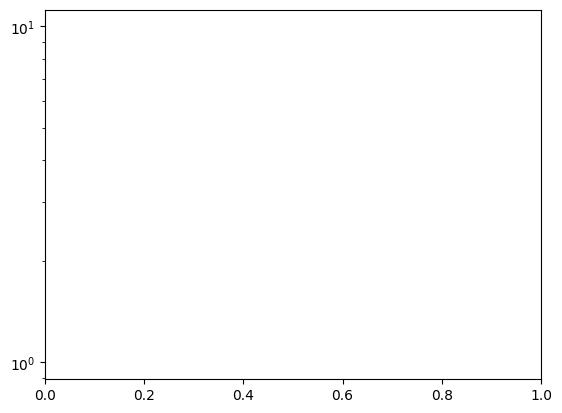

In [212]:
# espectros
f, Pxx_audio = signal.welch(audio_ruidoso, fs, nperseg=1024)
f, Pxx_fir = signal.welch(audio_fir, fs, nperseg=1024)
f, Pxx_iir = signal.welch(audio_iir, fs, nperseg=1024)


# Plot
plt.semilogy(f, Pxx_audio, label='Original (com ruído)')
plt.semilogy(f, Pxx_fir, label='FIR (Hamming)')
plt.semilogy(f, Pxx_iir, label='IIR (Butterworth)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Densidade espectral')
plt.axvline(x=18000, color='r', linestyle='--', label='18 kHz')
plt.axvline(x=0, color='r', linestyle=':', label='0 Hz')
plt.legend()
plt.title('Comparação espectral após filtragem')
plt.grid()
plt.xlim(-1000, 20000)
plt.show()


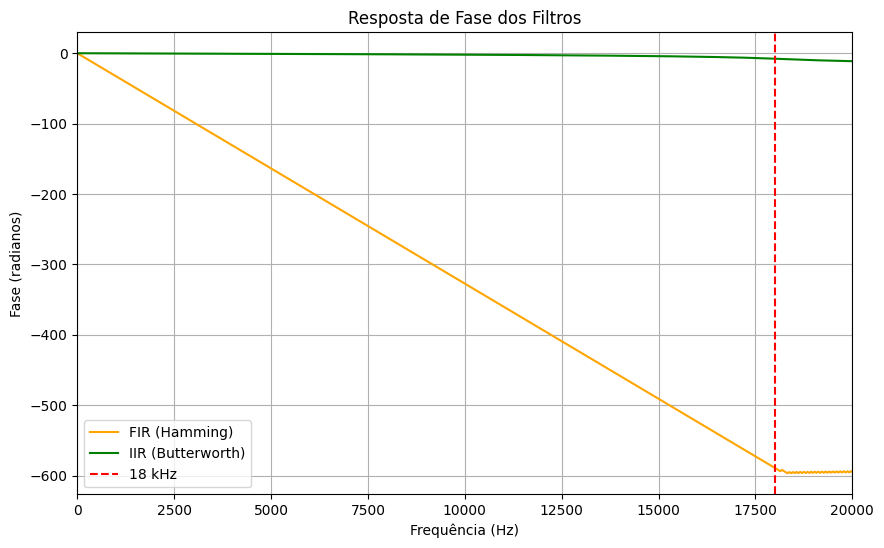

In [ ]:
# FIR
fir_coeff = signal.firwin(501, 18000/(48000/2), window='hamming')
w_fir, h_fir = signal.freqz(fir_coeff, fs=48000)
phase_fir = np.unwrap(np.angle(h_fir))

# IIR
b_iir, a_iir = signal.butter(10, 18000/(48000/2), btype='lowpass')
w_iir, h_iir = signal.freqz(b_iir, a_iir, fs=48000)
phase_iir = np.unwrap(np.angle(h_iir))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(w_fir, phase_fir, label='FIR (Hamming)', color='orange')
plt.plot(w_iir, phase_iir, label='IIR (Butterworth)', color='green')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')
plt.axvline(x=18000, color='red', linestyle='--', label='18 kHz')
plt.legend()
plt.grid()
plt.xlim(0, 20000)
plt.title('Resposta de Fase dos Filtros')
plt.show()

<p style="text-align: justing;">Um filtro tem fase linear na banda de passagem quando o atraso de fase introduzido pelo filtro varia linearmente com a frequência, ou seja, quando a derivada primeira da fase em função da frequência resulta em uma constante. Matematicamente, isso significa que a fase obedece a:</p>

$${\phi(\omega) = -D \cdot \omega + C}~~~~~~~~~~~~~~~~~~~~~~~~~~~(1)$$

onde:

- $D$ é o atraso de grupo constante(em segundos),
- $C$ é uma constante(geralmente 0 ou multiplo de $\pi$),
- $\omega$ é a frequência angular. 

<div style="text-align: justing;">

**IMPLICAÇÕES PRÁTICAS**  
• Preservação da forma de onda, ou seja, sinais na banda de passagem **não sofrem distorção de fase**, ou ainda: componentes de frequêcia diferentes são atrasados pelo mesmo tempo.

• Para que a derivada em $(1)$ seja constante, ou melhor, o **Atraso de grupo constante** os filtros devem apresentar resposta de fase linear, que nesse caso apenas o filtro FIR atende ao este requisito.

• A distorção de fase, ou ainda, a não-linearidade no atraso das diferentes componentes de frequência gera "sujeiras(*smearing*)" nos transientes dos sinais.

• Em contra partida, a não linearidade dos filtros IIR na música é útil para o "Tempero Artístico": pode-se reforçar(+gain) ou atenuar(-gain) em uma determinada frequência, a não linearidade também é ideal para projetos de sintetizadores digitais e efeitos sonoros mais diversos, onde "bagunçar" a fase dos frequência é o objetivo.

• Filtros IIR, também são últeis para sistemas embarcados, devido ao seu significativo número reduzido de coeficiêntes.

</div>

# IIR $\times$ FIR #

| Característica               | IIR                            | FIR                            |
|------------------------------|--------------------------------|--------------------------------|
| **Número de coeficientes**    | ✅ Menos para mesma atenuação  | ❌ Precisa de mais coeficientes |
| **Fase**                     | ❌ Não linear (distorção temporal) | ✅ Linear (preserva forma de onda) |
| **Atraso de processamento**  | ✅ Baixo                       | ❌ Alto (depende da ordem)     |
| **Estabilidade numérica**    | ❌ Risco de instabilidade      | ✅ Inerentemente estável       |
| **Eficiência em hardware**   | ✅ Alta (DSP/FPGA)             | ❌ Consome mais recursos       |
| **Projeto de fase linear**   | ❌ Difícil                     | ✅ Fácil                       |

